# Multi-seed reproducibility — o teste decisivo

Pergunta: o resultado AUC = 0.709 da Etapa 4 é **reproduzível** ou é um sorteio sortudo de uma distribuição de alta variância?

Procedimento:

1. Treinar o **Transformer Etapa 4** (11 preço + 5 sentimento FinBERT) **20 vezes** com seeds diferentes em ITUB4.
2. Treinar o **dumb baseline** (XGBoost, 5 features autoregressivas, sem sentimento) **20 vezes** em ITUB4.
3. Para cada seed, coletar:
   - AUC
   - precision(Desce), recall(Desce)
   - precision(Sobe), recall(Sobe)
   - número de "down calls" (quantas vezes o modelo prediz Desce)
4. Comparar **distribuições**, não pontos.

## Critério de decisão

| Padrão observado em 20 seeds | Conclusão | Tese |
|---|---|---|
| `precision(Desce)` do Transformer **≥ 0.85** em ≥ 80% das seeds, e baseline fica em 0.50–0.65 | **Achado real**: detector de cauda de alta precisão. | Reframe como *tail-risk filter*. |
| AUC do Transformer com média ≈ AUC do baseline e CIs sobrepostos | Sentimento não adiciona valor distinguível. | Pivotar para *comparação de representações* (Etapa 3 vs 4). |
| AUC do Transformer com mediana muito abaixo de 0.709 (digamos < 0.55) | 0.709 foi sorte. | Reportar honestamente — virou achado metodológico sobre fragilidade de seeds em low-data ML financeiro. |

In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from eval_utils import walk_forward_split, make_binary_target

PRICE_PATH = '../2.stocks/dataset_full.csv'
SENTIMENT_PATH = '../4.finbert-br/itub4_daily_sentiment.csv'
HORIZON = 21
WINDOW = 30
N_SEEDS = 20
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cuda


## 1. Construir o dataset uma única vez

O split é fixo (walk-forward 70/15/15). Só os seeds de treinamento variam.

In [2]:
PRICE_COLS = ['Close','Volume','return','ma7','ma21','std21','lag_1','lag_2','lag_3','lag_4','lag_5']
SENT_COLS = ['n_articles','mean_logit_pos','mean_logit_neg','mean_logit_neu','mean_sentiment']
BASELINE_FEATURES = ['return','lag_1','lag_5','Volume','std21']
FULL_FEATURES = PRICE_COLS + SENT_COLS

px = pd.read_csv(PRICE_PATH, parse_dates=['Date']).rename(columns={'Date':'date'})
px = px[['date'] + PRICE_COLS].sort_values('date').reset_index(drop=True)
sent = pd.read_csv(SENTIMENT_PATH, parse_dates=['date'])[['date'] + SENT_COLS]
df = px.merge(sent, on='date', how='left').sort_values('date').reset_index(drop=True)
df[SENT_COLS] = df[SENT_COLS].ffill().fillna(0)
df['target'] = make_binary_target(df['Close'], horizon=HORIZON)
df = df.dropna(subset=['target']).reset_index(drop=True)

train_df, val_df, test_df = walk_forward_split(df)
print(f'Train: {len(train_df)} | balance up = {train_df["target"].mean():.3f}')
print(f'Val:   {len(val_df)} | balance up = {val_df["target"].mean():.3f}')
print(f'Test:  {len(test_df)} | balance up = {test_df["target"].mean():.3f}')
print(f'\nDistribution shift train→test: Δ = {test_df["target"].mean() - train_df["target"].mean():+.3f}')

Train: 844 | balance up = 0.570
Val:   180 | balance up = 0.583
Test:  182 | balance up = 0.692

Distribution shift train→test: Δ = +0.122


In [3]:
def make_windows(X, y, window=WINDOW):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i]); ys.append(y[i])
    return np.array(Xs), np.array(ys)

def collect_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return {
        'auc':         roc_auc_score(y_true, y_score),
        'prec_down':   precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        'recall_down': recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'prec_up':     precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_up':   recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'n_down_calls': int(cm[:, 0].sum()),  # quantas vezes previu Desce
        'n_test':       int(len(y_true)),
    }

## 2. Pipelines de treino (uma seed cada)

In [4]:
class Stage4Transformer(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, nlayers=2, window=WINDOW):
        super().__init__()
        self.proj = nn.Linear(n_features, d_model)
        pe = torch.zeros(window, d_model)
        pos = torch.arange(0, window).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos*div); pe[:, 1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=0.2, batch_first=True)
        self.enc = nn.TransformerEncoder(layer, num_layers=nlayers)
        self.head = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(0.3), nn.Linear(32, 1))
    def forward(self, x):
        h = self.proj(x) + self.pe[:, :x.size(1), :]
        h = self.enc(h)
        return self.head(h.mean(dim=1)).squeeze(-1)

def train_transformer_one_seed(seed):
    torch.manual_seed(seed); np.random.seed(seed)
    sc = StandardScaler().fit(train_df[FULL_FEATURES])
    Xtr = sc.transform(train_df[FULL_FEATURES]); ytr = train_df['target'].values.astype(int)
    Xva = sc.transform(val_df[FULL_FEATURES]);   yva = val_df['target'].values.astype(int)
    Xte = sc.transform(test_df[FULL_FEATURES]);  yte = test_df['target'].values.astype(int)
    Xtw, ytw = make_windows(Xtr, ytr)
    Xvw, yvw = make_windows(Xva, yva)
    Xew, yew = make_windows(Xte, yte)

    model = Stage4Transformer(n_features=len(FULL_FEATURES)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    pos = (ytw==1).sum(); neg = (ytw==0).sum()
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([neg/max(pos,1)], device=device, dtype=torch.float32))

    Xt_t = torch.tensor(Xtw, dtype=torch.float32, device=device)
    yt_t = torch.tensor(ytw, dtype=torch.float32, device=device)
    Xv_t = torch.tensor(Xvw, dtype=torch.float32, device=device)
    yv_t = torch.tensor(yvw, dtype=torch.float32, device=device)
    Xe_t = torch.tensor(Xew, dtype=torch.float32, device=device)

    best=float('inf'); best_state=None; bad=0; patience=15
    for epoch in range(200):
        model.train(); opt.zero_grad()
        loss = loss_fn(model(Xt_t), yt_t); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        model.eval()
        with torch.no_grad():
            vl = loss_fn(model(Xv_t), yv_t).item()
        if vl < best - 1e-4:
            best=vl; best_state={k:v.clone() for k,v in model.state_dict().items()}; bad=0
        else:
            bad += 1
            if bad >= patience: break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        y_score = torch.sigmoid(model(Xe_t)).cpu().numpy()
    return collect_metrics(yew, y_score)

def train_baseline_one_seed(seed):
    np.random.seed(seed)
    sc = StandardScaler().fit(train_df[BASELINE_FEATURES])
    Xtr = sc.transform(train_df[BASELINE_FEATURES]); ytr = train_df['target'].values.astype(int)
    Xva = sc.transform(val_df[BASELINE_FEATURES]);   yva = val_df['target'].values.astype(int)
    Xte = sc.transform(test_df[BASELINE_FEATURES]);  yte = test_df['target'].values.astype(int)
    pos = (ytr==1).sum(); neg = (ytr==0).sum()
    m = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=neg/max(pos,1), eval_metric='auc', random_state=seed,
    )
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    return collect_metrics(yte, m.predict_proba(Xte)[:,1])

## 3. Loop multi-seed (≈ 5–10 minutos em GPU, mais em CPU)

In [5]:
rows = []
t0 = time.time()
for seed in range(N_SEEDS):
    rt = train_transformer_one_seed(seed)
    rt['model'] = 'transformer_finbert'; rt['seed'] = seed
    rows.append(rt)
    rb = train_baseline_one_seed(seed)
    rb['model'] = 'baseline_xgb'; rb['seed'] = seed
    rows.append(rb)
    elapsed = time.time() - t0
    print(f'seed {seed:2d} | trans AUC={rt["auc"]:.3f} prec_down={rt["prec_down"]:.2f} n_down={rt["n_down_calls"]:3d} | base AUC={rb["auc"]:.3f} prec_down={rb["prec_down"]:.2f} n_down={rb["n_down_calls"]:3d} | {elapsed:.0f}s')

results = pd.DataFrame(rows)
results.to_csv('results_multi_seed.csv', index=False)
print(f'\nDone. {len(results)} runs in {time.time()-t0:.0f}s')

seed  0 | trans AUC=0.822 prec_down=0.00 n_down=  0 | base AUC=0.651 prec_down=0.31 n_down=175 | 2s
seed  1 | trans AUC=0.919 prec_down=0.24 n_down=152 | base AUC=0.657 prec_down=0.31 n_down=179 | 3s
seed  2 | trans AUC=0.789 prec_down=0.24 n_down=152 | base AUC=0.652 prec_down=0.31 n_down=178 | 3s
seed  3 | trans AUC=0.080 prec_down=0.00 n_down= 39 | base AUC=0.615 prec_down=0.31 n_down=176 | 4s
seed  4 | trans AUC=0.107 prec_down=0.00 n_down=  0 | base AUC=0.633 prec_down=0.32 n_down=174 | 4s
seed  5 | trans AUC=0.858 prec_down=0.00 n_down=  0 | base AUC=0.647 prec_down=0.32 n_down=177 | 5s
seed  6 | trans AUC=0.811 prec_down=0.24 n_down=149 | base AUC=0.628 prec_down=0.31 n_down=180 | 5s
seed  7 | trans AUC=0.823 prec_down=1.00 n_down=  6 | base AUC=0.633 prec_down=0.31 n_down=178 | 6s
seed  8 | trans AUC=0.831 prec_down=0.24 n_down=152 | base AUC=0.646 prec_down=0.31 n_down=179 | 6s
seed  9 | trans AUC=0.802 prec_down=0.24 n_down=152 | base AUC=0.638 prec_down=0.31 n_down=179 | 7s


## 4. Estatísticas agregadas por modelo

In [6]:
agg = results.groupby('model').agg(
    auc_mean=('auc','mean'), auc_std=('auc','std'),
    auc_median=('auc','median'),
    auc_min=('auc','min'), auc_max=('auc','max'),
    prec_down_mean=('prec_down','mean'), prec_down_std=('prec_down','std'),
    recall_down_mean=('recall_down','mean'),
    n_down_mean=('n_down_calls','mean'),
).round(3)
print(agg.to_string())
agg.to_csv('multi_seed_summary.csv')

                     auc_mean  auc_std  auc_median  auc_min  auc_max  prec_down_mean  prec_down_std  recall_down_mean  n_down_mean
model                                                                                                                             
baseline_xgb            0.641    0.012       0.638    0.615    0.660           0.313          0.002             0.993        177.4
transformer_finbert     0.686    0.261       0.802    0.080    0.931           0.177          0.253             0.433         63.2


In [7]:
# Quantas seeds o Transformer atinge precision_down >= 0.85?
tr = results[results.model=='transformer_finbert']
ba = results[results.model=='baseline_xgb']
high_prec_seeds_tr = (tr['prec_down'] >= 0.85).sum()
high_prec_seeds_ba = (ba['prec_down'] >= 0.85).sum()
auc_above_065_tr = (tr['auc'] >= 0.65).sum()
auc_above_065_ba = (ba['auc'] >= 0.65).sum()
print(f'Transformer: precision_down ≥ 0.85 em {high_prec_seeds_tr}/{N_SEEDS} seeds | AUC ≥ 0.65 em {auc_above_065_tr}/{N_SEEDS}')
print(f'Baseline:    precision_down ≥ 0.85 em {high_prec_seeds_ba}/{N_SEEDS} seeds | AUC ≥ 0.65 em {auc_above_065_ba}/{N_SEEDS}')

# A pergunta original — onde cai 0.709 na distribuição?
auc_vals = tr['auc'].values
pct_at_or_above_709 = (auc_vals >= 0.709).mean() * 100
print(f'\nNo Transformer, {pct_at_or_above_709:.0f}% das seeds atingem AUC ≥ 0.709 — é tail ou típico?')

Transformer: precision_down ≥ 0.85 em 1/20 seeds | AUC ≥ 0.65 em 15/20
Baseline:    precision_down ≥ 0.85 em 0/20 seeds | AUC ≥ 0.65 em 7/20

No Transformer, 65% das seeds atingem AUC ≥ 0.709 — é tail ou típico?


## 5. Histogramas — onde 0.709 cai na distribuição?

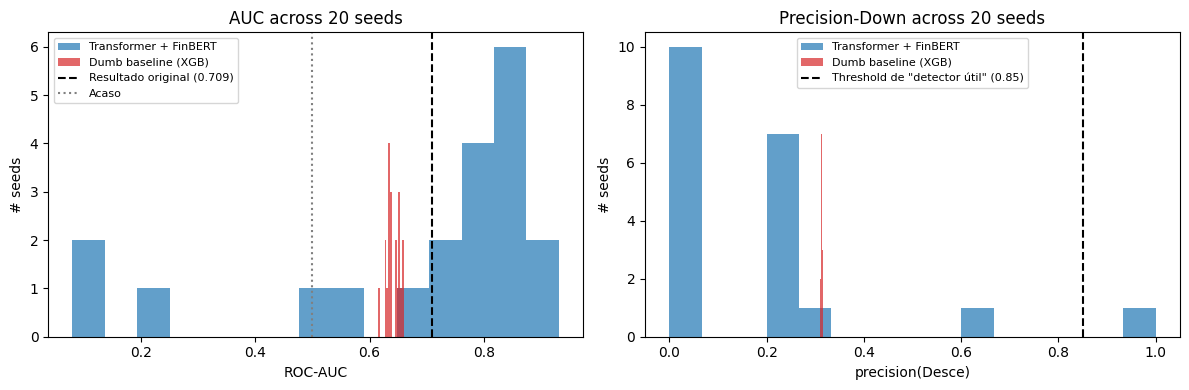

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(tr['auc'], bins=15, alpha=0.7, label='Transformer + FinBERT', color='C0')
axes[0].hist(ba['auc'], bins=15, alpha=0.7, label='Dumb baseline (XGB)', color='C3')
axes[0].axvline(0.709, ls='--', color='k', label='Resultado original (0.709)')
axes[0].axvline(0.5, ls=':', color='gray', label='Acaso')
axes[0].set_xlabel('ROC-AUC'); axes[0].set_ylabel('# seeds')
axes[0].set_title('AUC across 20 seeds')
axes[0].legend(fontsize=8)

axes[1].hist(tr['prec_down'], bins=15, alpha=0.7, label='Transformer + FinBERT', color='C0')
axes[1].hist(ba['prec_down'], bins=15, alpha=0.7, label='Dumb baseline (XGB)', color='C3')
axes[1].axvline(0.85, ls='--', color='k', label='Threshold de "detector útil" (0.85)')
axes[1].set_xlabel('precision(Desce)'); axes[1].set_ylabel('# seeds')
axes[1].set_title('Precision-Down across 20 seeds')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('multi_seed_histograms.png', dpi=120, bbox_inches='tight')
plt.show()

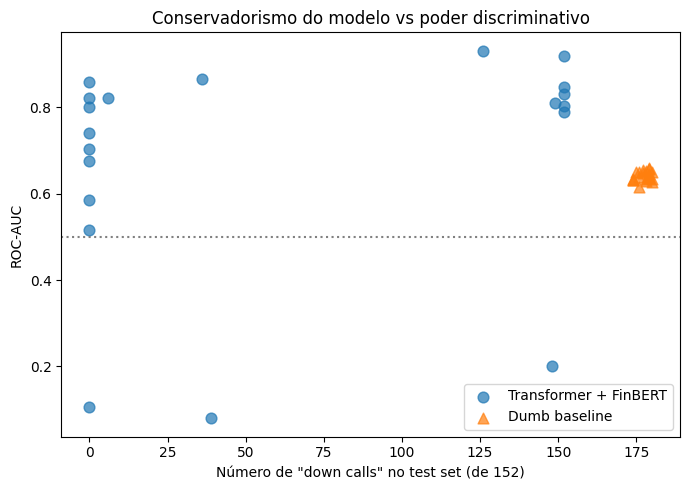

In [9]:
# Scatter: AUC vs n_down_calls — entender o trade-off
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(tr['n_down_calls'], tr['auc'], label='Transformer + FinBERT', s=60, alpha=0.7)
ax.scatter(ba['n_down_calls'], ba['auc'], label='Dumb baseline', s=60, alpha=0.7, marker='^')
ax.set_xlabel('Número de "down calls" no test set (de {})'.format(int(tr['n_test'].iloc[0])))
ax.set_ylabel('ROC-AUC')
ax.set_title('Conservadorismo do modelo vs poder discriminativo')
ax.axhline(0.5, ls=':', color='gray')
ax.legend()
plt.tight_layout()
plt.savefig('multi_seed_tradeoff.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Decisão

Olhe os outputs acima e classifique seu cenário:

**Cenário 1 — "Tail detector real"**
- `precision_down_mean` do Transformer ≥ 0.80 *e* `prec_down_mean` do baseline ≤ 0.65
- → você tem um detector de cauda. Reframe a tese como **filtro de drawdown de alta precisão**.
- Próximo passo: backtest simples (long ITUB4 exceto quando o modelo grita "down" — vai a caixa por 21 dias) vs buy-and-hold.

**Cenário 2 — "0.709 foi sorte"**
- AUC mediana do Transformer < 0.55, com poucas seeds atingindo 0.709
- → reportar honestamente. A tese vira sobre **fragilidade de avaliação em low-data financial ML** — ainda publicável, mais rigorosa.

**Cenário 3 — "Baseline vence"**
- AUC do baseline ≈ ou > Transformer
- → o sentimento não está adicionando valor. Pivotar para **comparação de representações** (Etapa 3 vs 4: mesmo modelo, ablation entre Ollama 1024d e FinBERT 5d).

**Cenário 4 — "Distribution shift domina tudo"**
- Ambos os modelos têm AUC mediana ~ 0.5, alta variância, prec_down ~ class balance
- → o sinal não existe na configuração atual de split. **Mude o split**: experimente time-series CV com múltiplas janelas de teste em vez de uma única, ou use um horizonte diferente.